#**Procesamiento de imágenes digitales (Filtrando ruido con filtros adaptativos)**

#Montar colab y moverse a la carpeta donde se encuentran las imágenes

In [193]:
from google.colab import drive
drive.mount('/content/gdrive')
# Change to the specific folder
%cd "/content/gdrive/MyDrive/UIS/2026-1/Procesamiento de imágenes dígitales/Quices/ Quiz #6: Deconvolución"

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
/content/gdrive/MyDrive/UIS/2026-1/Procesamiento de imágenes dígitales/Quices/ Quiz #6: Deconvolución


# Librerias necesarias para la sesión

In [194]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# Cargue alguna imagen de interés para ser analizada

Recuerde que puede accederlas en:
 https://github.com/hfarueda/DIP/blob/main/Imagenes/

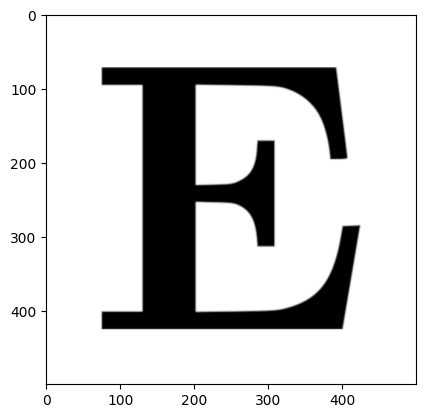

In [195]:
# cargar imagen y convertir a escala de grises
image = cv.imread('e_1.png')
img = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
plt.imshow(img, cmap='gray')
plt.show()

# Creando PSF y generando imagen distorsionada

In [196]:
from scipy.signal.windows import gaussian
def kernel(mode='box', kernel_size=3):

    # Kernel tipo box
    if mode == 'box':
        h = np.ones((kernel_size, kernel_size))
        h /= np.sum(h)

    # Kernel Gaussiano
    elif mode == 'gaussian':
        # Vector Gaussiano 1D
        g = gaussian(kernel_size, std=kernel_size/3)
        # Kernel 2D
        h = np.outer(g, g)
        # Normalización
        h /= np.sum(h)

    return h

# Reto No. 1. Genere una psf a su gusto (box o Gaussian) y genere la convolución

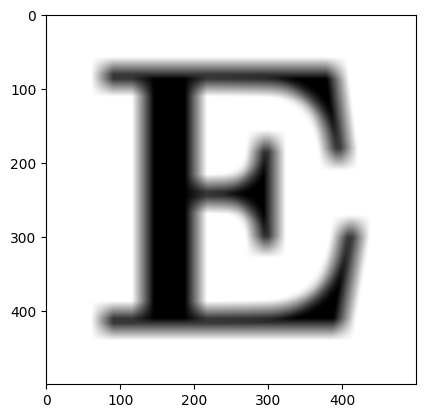

In [197]:
# Your code here
from scipy.signal import convolve2d
psf =  kernel('box', 30)     # genere PSF usando la función kernel
img_blur = convolve2d(img, psf, mode='same', boundary='symm')  # convolución de imagen con el kernel
plt.imshow(img_blur, cmap='gray')
plt.show()

In [198]:
# Ejemplo de salida

# Reto No. 2. Agregando ruido a la medición

In [199]:
def add_gaussian_noise(img, sigma):
    gauss = np.random.normal(0, sigma, np.shape(img))
    noisy_img = img + gauss
    noisy_img[noisy_img < 0] = 0
    noisy_img[noisy_img > 255] = 255
    return noisy_img

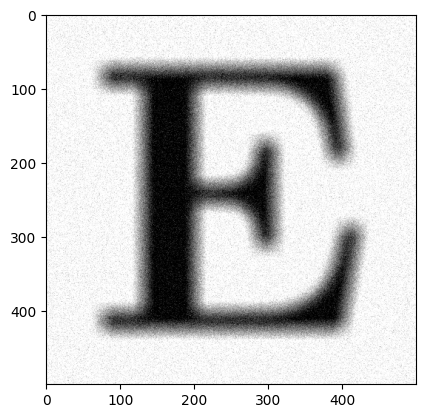

In [200]:
# Your code here
NOISE_STD = 20  # Desviación estandar del ruido
img_noisy = add_gaussian_noise(img_blur, NOISE_STD)  # Generación de imagen ruidosa
plt.imshow(img_noisy, cmap='gray')
plt.show()

In [201]:
# Ejemplo de ejecución

# Deconvolución Directa y Deconvolución Wiener

# Reto No 3. Construya las funciones de deconvolución inversa y de Wiener

In [202]:
def inverse(input, PSF, eps):  # Inverse filtering
    input_fft = np.fft.fft2(input)    # Transformada de Fourier de input
    PSF_fft =   np.fft.fft2(PSF, s=input.shape) + eps    # Transformada de Fourier del filtro + epsilon para evitar errores
    result =    np.fft.ifft2(input_fft / PSF_fft)    # Calcule la transformada inversa de Fourier de la división entre G y H
    result = np.abs(result) # Retorne la magnitud de la transformada
    return result

In [203]:
def wiener(input, PSF, eps, K=0.01):  # Wiener filtering，K=0.01
    input_fft =  np.fft.fft2(input)   # Transformada de Fourier de input
    PSF_fft =    np.fft.fft2(PSF, s=input.shape) + eps   # Transformada de Fourier del filtro + epsilon para evitar errores
    PSF_fft_1 =  np.conj(PSF_fft) / (np.abs(PSF_fft)**2 + K)   # Calcule el filtro de Wiener
    result = np.fft.ifft2(input_fft * PSF_fft_1)  # Calcule la transformada inversa de Fourier de la multiplicación entre G y H
    result = np.abs(result) # Retorne la magnitud de la transformada
    return result

# Pruebe la deconvolución con la imagen distorsionada y con la distorsionada + ruido


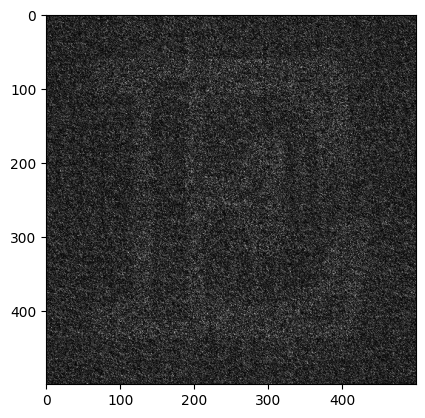

In [204]:
deconv_img_inv = inverse(img_noisy, psf, 1e-3)
plt.imshow(deconv_img_inv, cmap='gray')
plt.show()

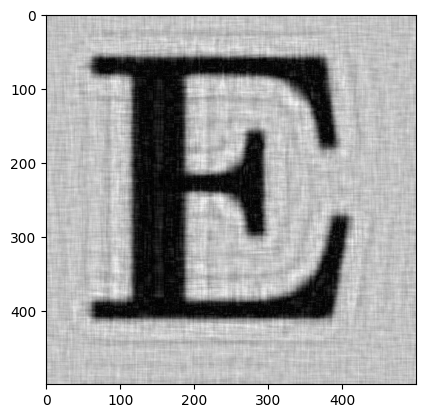

In [205]:
deconv_img_win = wiener(img_noisy, psf, 1e-3, K=0.01)
plt.imshow(deconv_img_win, cmap='gray')
plt.show()

# Reto No 4. Calcule el RMSE y el MAE

In [206]:
def calcular_errores(img_est, img_ref):
    ''' Calcular el error cuadrático medio (RMSE) y el error absoluto medio (MAE)
    entre las imágenes RGB de referencia y las estimadas '''
    RMSE = np.sqrt(np.mean((img_est - img_ref) ** 2)) ##
    MAE =  np.mean(np.abs(img_ref-img_est)) ##

    return RMSE, MAE

In [207]:
RMSE, MAE = calcular_errores(img, deconv_img_inv)
print('RMSE = ', RMSE)
print('MAE = ', MAE)

RMSE =  14944.050491709675
MAE =  11795.654525776805


In [208]:
RMSE, MAE = calcular_errores(img, deconv_img_win)
print('RMSE = ', RMSE)
print('MAE = ', MAE)

RMSE =  85.20974640814786
MAE =  45.6557646342546


# Simulando movimiento

In [209]:
# Simulated motion blur
def motion_process(image_size, motion_angle, tamano):
    PSF = np.zeros(image_size)
    print(image_size)
    center_position = (image_size[0] - 1) / 2
    print(center_position)

    slope_tan = np.tan(motion_angle * np.pi / 180)
    slope_cot = 1 / slope_tan
    if slope_tan <= 1:
        for i in range(tamano):
            offset = round(i * slope_tan)  # ((center_position-i)*slope_tan)
            PSF[int(center_position + offset), int(center_position - offset)] = 1
        return PSF / PSF.sum()  # Normalize the luminance of the point spread function
    else:
        for i in range(tamano):
            offset = round(i * slope_cot)
            PSF[int(center_position - offset), int(center_position + offset)] = 1
        return PSF / PSF.sum()

(500, 500)
249.5


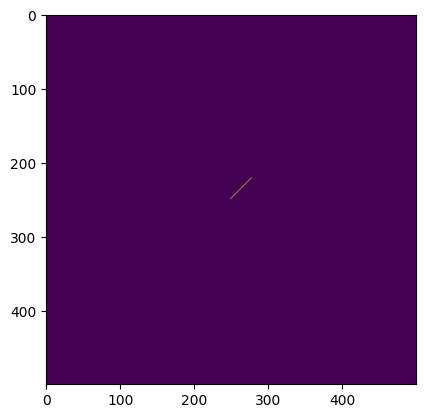

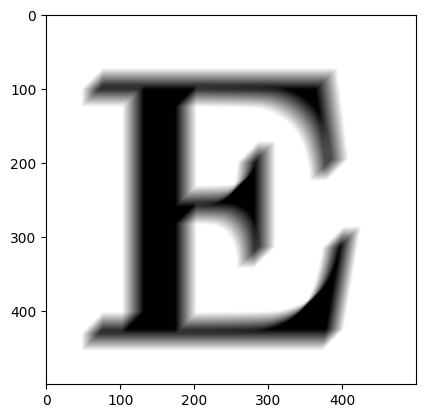

In [210]:
psf = motion_process(img.shape, motion_angle = 60, tamano = 50)
plt.imshow(psf)
plt.show()

img_blur = cv.filter2D(img, -1, psf)
plt.imshow(img_blur, cmap='gray')
plt.show()

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

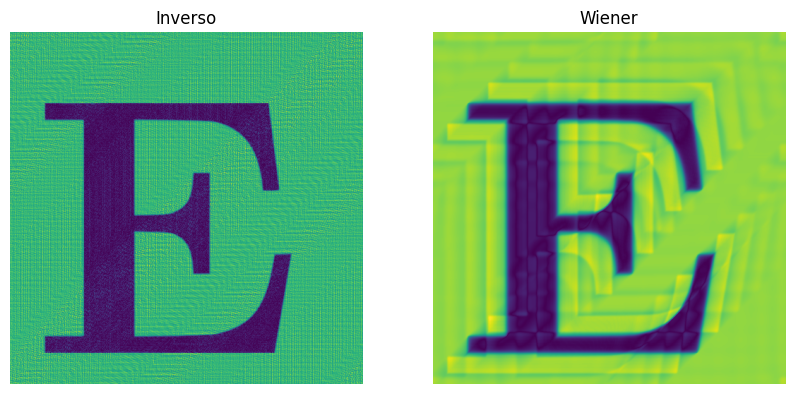

In [211]:
deconv_img_inv = inverse(img_blur, psf, 1e-3)
deconv_img_win = wiener(img_blur, psf, 1e-3, K=0.01)

plt.figure(figsize=(10,7))
plt.subplot(121), plt.imshow(np.fft.fftshift(deconv_img_inv)), plt.title('Inverso'); plt.axis('off')
plt.subplot(122), plt.imshow(np.fft.fftshift(deconv_img_win)), plt.title('Wiener'); plt.axis('off')

In [212]:
RMSE, MAE = calcular_errores(img, deconv_img_inv)
print('RMSE = ', RMSE)
print('MAE = ', MAE)

RMSE =  141.7100462945199
MAE =  94.25307198195199


In [213]:
RMSE, MAE = calcular_errores(img, deconv_img_win)
print('RMSE = ', RMSE)
print('MAE = ', MAE)

RMSE =  139.92178883887155
MAE =  87.59169182787211
